# 🛒 Olist Brazilian E-Commerce — Data Analysis

**Dataset:** Olist Brazilian E-Commerce Public Dataset (2016–2018)  
**Source:** Kaggle — olistbr/brazilian-ecommerce  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Business Question
> *Which product categories, states, and seller segments are driving Olist's revenue and satisfaction — and what operational changes will improve growth and retention over the next 2 quarters?*

---

## Table of Contents
1. [Imports](#1-imports)
2. [Data Loading](#2-data-loading)
3. [Assessment](#3-assessment)
4. [Merging](#4-merging)
5. [Exploratory Checks](#5-exploratory-checks)
6. [Cleaning](#6-cleaning)
7. [Feature Engineering](#7-feature-engineering)
8. [Sales & Revenue Analysis](#8-sales--revenue-analysis)
9. [Delivery & Operations Analysis](#9-delivery--operations-analysis)
10. [Customer Behaviour Analysis](#10-customer-behaviour-analysis)
11. [Seller Analysis](#11-seller-analysis)
12. [Key Findings & Recommendations](#12-key-findings--recommendations)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Imports

Importing all required libraries.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


## 2. Data Loading

Downloading the dataset from Kaggle using `kagglehub`.

In [ ]:
customer = pd.read_csv(path + "/olist_customers_dataset.csv")
orders= pd.read_csv(path + "/olist_orders_dataset.csv")
order_items=pd.read_csv(path + "/olist_order_items_dataset.csv")
order_payments=pd.read_csv(path + "/olist_order_payments_dataset.csv")
order_reviews=pd.read_csv(path + "/olist_order_reviews_dataset.csv")
products=pd.read_csv(path + "/olist_products_dataset.csv")
sellers=pd.read_csv(path + "/olist_sellers_dataset.csv")
geolocation=pd.read_csv(path + "/olist_geolocation_dataset.csv")
product_category=pd.read_csv(path + "/product_category_name_translation.csv")


## 3. Assessment

Before merging or cleaning, we inspect each table individually to understand its structure and note potential issues.

#ASSESMENT

  #Customer tabel

*   unique customer have multiple customere_id corresponding to unique order_Id

 #Order Item


*   unique order_id have n rows for n items in the order(same product)

 #Order Payment


*   unique order_id -> n rows for n payment method with diff or same payment type with diff or same value in each sequence
*   an order can be paid for in installments

 #Order Review


*   more tham 50% review massage missing, hence sentiment analysis not possibel, but review score is present

 #product

*   610 unique product id does not have a category







#Gole
 Which product categories, states, and seller segments are driving Olist's revenue and satisfaction — and what operational changes will improve growth and retention over the next 2 quarters?

## 4. Merging

Merging all 8 relevant tables into one master dataframe using appropriate join keys.  
`geolocation` is excluded — not needed for this analysis.

In [ ]:
df=(orders.merge(order_items,on="order_id")
         .merge(customer,on='customer_id')
         .merge(products,on='product_id')
         .merge(product_category,on='product_category_name')
         .merge(order_payments,on="order_id")
         .merge(order_reviews,on="order_id")
         .merge(sellers,on='seller_id'))

## 5. Exploratory Checks

Checking the shape, data types, and missing values of the merged dataframe.

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840,guariba,SP


In [ ]:
df.info()
#DateTime object not in right datatype
#data has some missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115609 entries, 0 to 115608
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       115609 non-null  object 
 1   customer_id                    115609 non-null  object 
 2   order_status                   115609 non-null  object 
 3   order_purchase_timestamp       115609 non-null  object 
 4   order_approved_at              115595 non-null  object 
 5   order_delivered_carrier_date   114414 non-null  object 
 6   order_delivered_customer_date  113209 non-null  object 
 7   order_estimated_delivery_date  115609 non-null  object 
 8   order_item_id                  115609 non-null  int64  
 9   product_id                     115609 non-null  object 
 10  seller_id                      115609 non-null  object 
 11  shipping_limit_date            115609 non-null  object 
 12  price                         

In [ ]:
df.isnull().sum()
#columns that has missing values and how many

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1195
order_delivered_customer_date,2400
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [ ]:
#status group of approved orders
Order_status_group= df[~df['order_approved_at'].isnull()].groupby('order_status').agg(Total_orders= ('order_id','nunique')).reset_index()
Order_status_group.to_csv('Order_status_group.csv', index=False)


In [ ]:
#orders with missing delivery date order status group
df[df['order_delivered_customer_date'].isnull()].groupby('order_status')['order_status'].count()

,order_status
order_status,
approved,3
canceled,529
delivered,8
invoiced,358
processing,357
shipped,1138
unavailable,7


In [ ]:
new=df[df['order_delivered_customer_date'].isnull() & ~df['order_delivered_carrier_date'].isnull()].sort_values(by='order_status')
new[['order_id','order_status','shipping_limit_date','order_delivered_carrier_date','order_delivered_customer_date']]

,order_id,order_status,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date
77991,8d171a848151e69e8f090fdbb50d4010,canceled,2018-02-21 03:07:13,2018-02-16 00:19:33,NaN
22500,b7d469b7eb3c07c6d4b96d505c811fea,canceled,2018-02-12 03:51:16,2018-02-06 20:46:55,NaN
63978,cd408efeda0fdd3fe5f27134bd065001,canceled,2018-02-14 22:30:25,2018-02-09 23:46:35,NaN
52159,8652f7789fe1585b439154b7ae0f4285,canceled,2018-02-26 15:09:18,2018-02-21 21:23:04,NaN
102444,ca7296a83aa279afb28c2388a4f48891,canceled,2018-02-15 10:10:17,2018-02-08 23:26:57,NaN
...,...,...,...,...,...
37252,74cac755eeb7be9b59c009ac2e5b3241,shipped,2018-03-21 22:28:10,2018-03-20 16:58:25,NaN
37138,2b0d020da35221c291bb03a55f70794a,shipped,2018-04-06 20:49:57,2018-04-06 01:02:27,NaN
37112,736813b41544d3ca0ed5d508802f4ca1,shipped,2017-09-21 09:15:13,2017-09-20 20:41:38,NaN
38786,6a796b64b820d098a93b2f1351cd1e59,shipped,2018-04-19 02:31:41,2018-04-19 17:21:28,NaN


#Python assessment

  #Missing value

*   missing values in order_approved_at, order_delivered_customer_date, product_category_name are a problem for analysis

*   `order_delivered_customer_date` missing values row has only 8 delivered orders
*  `product_category_name` has 1695 missing values, cant remove rows as they have review and delivery

 #order status dependency


*   review score and delivery date depends on order status


1.   missing delivery date has order wit 8 delivered status
2.   data with delivery data has 7 cancled (order cancled but yet deliverd?) rest delivered orders
3.   review score avg changes according to status








## 6. Cleaning

### 6.1 DateTime Conversion
All timestamp columns are stored as `object` (string). Converting them to proper `datetime` type.

#CLEANING

In [ ]:
#date time conversion
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at']=pd.to_datetime(df['order_approved_at'])
df['order_delivered_customer_date']=pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date']=pd.to_datetime(df['order_estimated_delivery_date'])
df['review_creation_date']=pd.to_datetime(df['review_creation_date'])

Verifying the datetime conversion was successful.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115609 entries, 0 to 115608
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115609 non-null  object        
 1   customer_id                    115609 non-null  object        
 2   order_status                   115609 non-null  object        
 3   order_purchase_timestamp       115609 non-null  datetime64[ns]
 4   order_approved_at              115595 non-null  datetime64[ns]
 5   order_delivered_carrier_date   114414 non-null  object        
 6   order_delivered_customer_date  113209 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115609 non-null  datetime64[ns]
 8   order_item_id                  115609 non-null  int64         
 9   product_id                     115609 non-null  object        
 10  seller_id                      115609 non-null  object        
 11  

## 7. Feature Engineering

Creating new derived columns that will be used throughout the analysis.

#FEATURE ENGINEERING

Checking the dataframe before adding new columns.

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP


### 7.1 Purchase Month & Year

In [ ]:
# creating seperate columns for purchase month and year
df['order_month']= df['order_purchase_timestamp'].dt.to_period('M')
df['order_year']= df['order_purchase_timestamp'].dt.to_period('Y')


### 7.2 Delivery Time in Days

Calculating actual delivery time = `order_delivered_customer_date` − `order_purchase_timestamp`.

In [ ]:
#column for delivery time in days
df['delivery_time']=df['order_delivered_customer_date']-df['order_purchase_timestamp']
df['delivery_time']=df['delivery_time'].dt.days

### 7.3 On-Time vs Late Flag

If estimated delivery date > actual delivery date → **On-Time**, else → **Late**.

In [ ]:
# column for estimate delivery vs actual delivery
delivery=df['order_estimated_delivery_date']-df['order_delivered_customer_date']
delivery=delivery.dt.days
df['actual_delivery_time']=np.where(delivery>0,'Ontime','Late')

### 7.4 Revenue Column

`revenue = price + freight_value` (total amount paid per item including shipping).

In [ ]:
#adding revenue columan
df['revenue']= df['price']+df['freight_value']

Verifying all new columns were created correctly.

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,order_month,order_year,delivery_time,actual_delivery_time,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-11,2017-10-12 03:43:48,9350,maua,SP,2017-10,2017,8.0,Ontime,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-11,2017-10-12 03:43:48,9350,maua,SP,2017-10,2017,8.0,Ontime,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-11,2017-10-12 03:43:48,9350,maua,SP,2017-10,2017,8.0,Ontime,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,2018-07,2018,13.0,Ontime,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,2018-08,2018,9.0,Ontime,179.12


### 7.5 Creating `df_clean`

For **revenue, delivery, and seller analysis** we use only completed (delivered) orders with a valid delivery date.  
The full `df` is retained for order status and review distribution analysis.

| DataFrame | Used For |
|---|---|
| `df` | Order status analysis, review distributions |
| `df_clean` | Revenue, delivery, customer, seller analysis |

In [ ]:
# Keep only delivered orders for analysis
df_clean = df[df['order_status'] == 'delivered'].copy()
df_clean = df_clean.dropna(subset=['order_delivered_customer_date'])
df_clean = df_clean[df_clean['payment_type'] != 'not_defined']
df_clean = df_clean[df_clean['payment_value'] > 0]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")


Rows before cleaning: 115609
Rows after cleaning: 113198


In [ ]:
df_payment= df_clean


In [ ]:
#removing dublicate orders based on order id , product id and seller id
df_clean.drop_duplicates(subset=['order_id', 'product_id', 'seller_id'], inplace=True)
df_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,order_month,order_year,delivery_time,actual_delivery_time,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-11,2017-10-12 03:43:48,9350,maua,SP,2017-10,2017,8.0,Ontime,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,2018-07,2018,13.0,Ontime,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,2018-08,2018,9.0,Ontime,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-12-03,2017-12-05 19:21:58,31842,belo horizonte,MG,2017-11,2017,13.0,Ontime,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-17,2018-02-18 13:02:51,8752,mogi das cruzes,SP,2018-02,2018,2.0,Ontime,28.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115603,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1,ac35486adb7b02598c182c2ff2e05254,...,2017-03-22,2017-03-23 11:02:08,12913,braganca paulista,SP,2017-03,2017,8.0,Ontime,85.08
115604,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,2018-03-01,2018-03-02 17:50:01,17602,tupa,SP,2018-02,2018,22.0,Ontime,195.00
115605,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,2017-09-22,2017-09-22 23:10:57,8290,sao paulo,SP,2017-08,2017,24.0,Ontime,271.01
115606,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,2018-01-26,2018-01-27 09:16:56,37175,ilicinea,MG,2018-01,2018,17.0,Ontime,220.58


## 8. Sales & Revenue Analysis

Identifying revenue trends, top/bottom performing categories, average order value, and payment behaviour.

> All charts in this section use `df_clean` (delivered orders only) unless stated otherwise.

#Sale and revenue analysis

### 8.1 Monthly Revenue Trend

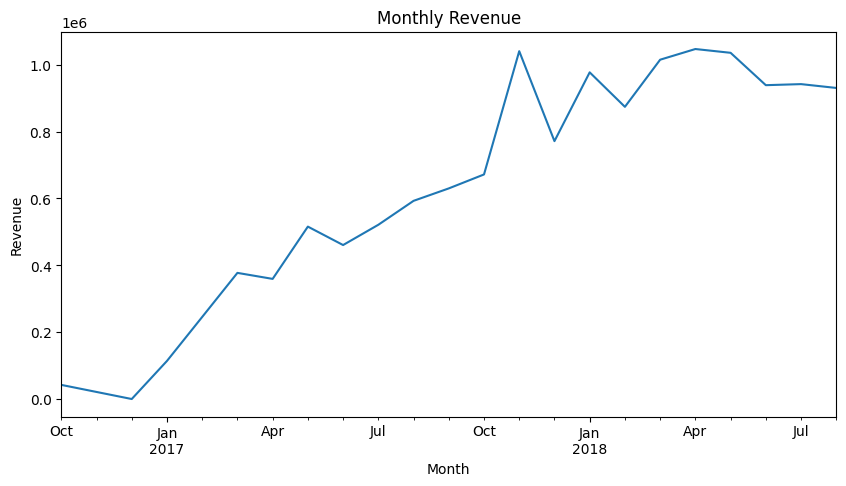

In [ ]:
plt.figure(figsize=(10,5))
df_clean.groupby('order_month')['revenue'].sum().plot(kind='line')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### 8.2 Month-over-Month Revenue Growth (%)

In [ ]:
#month on month revenue growth
df_clean.groupby('order_month')['revenue'].sum().pct_change()*100



,revenue
order_month,
2016-10,NaN
2016-12,-99.953633
2017-01,580478.134557
2017-02,115.501491
2017-03,53.705910
2017-04,-4.762924
2017-05,43.512366
2017-06,-10.687917
2017-07,13.158636


### 8.3 Top 10 Product Categories by Revenue

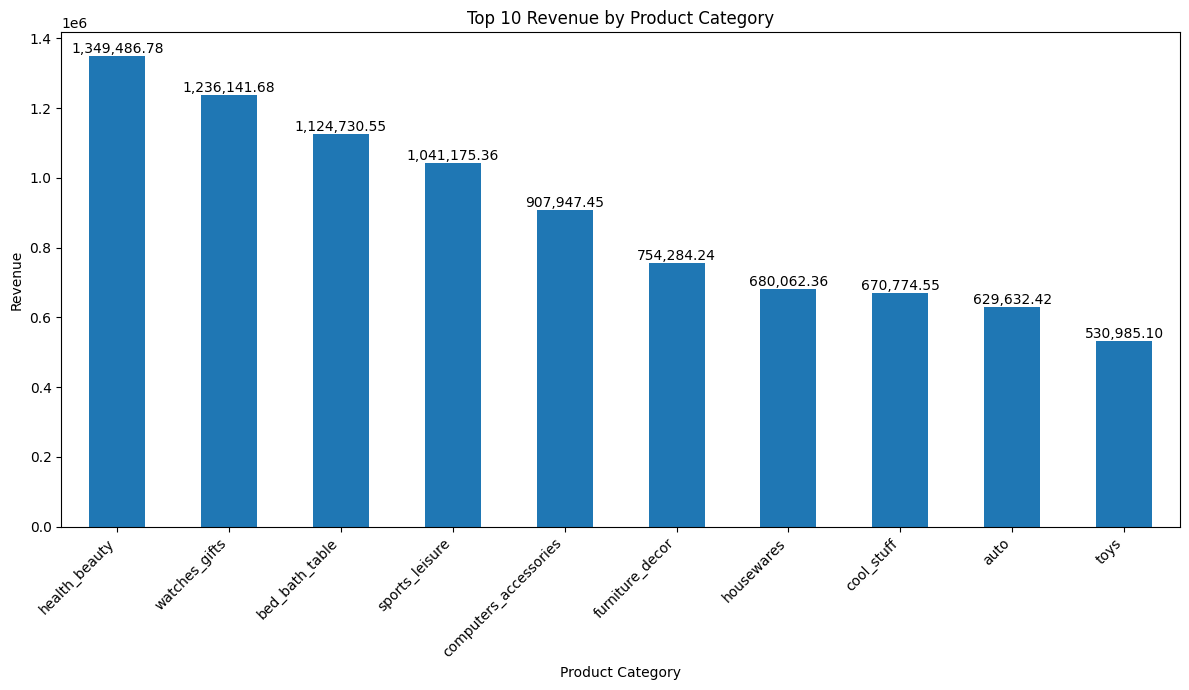

In [ ]:
#top performing categories
top_categories = df_clean.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
ax = top_categories.plot(kind='bar')
plt.title('Top 10 Revenue by Product Category')
plt.xlabel('Product Category') # X-axis is Product Category
plt.ylabel('Revenue') # Y-axis is  Revenue

# Add values on each bar
for index, value in enumerate(top_categories):
    ax.text(index, value, f'{value:,.2f}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

### 8.4 Bottom 10 Product Categories by Revenue

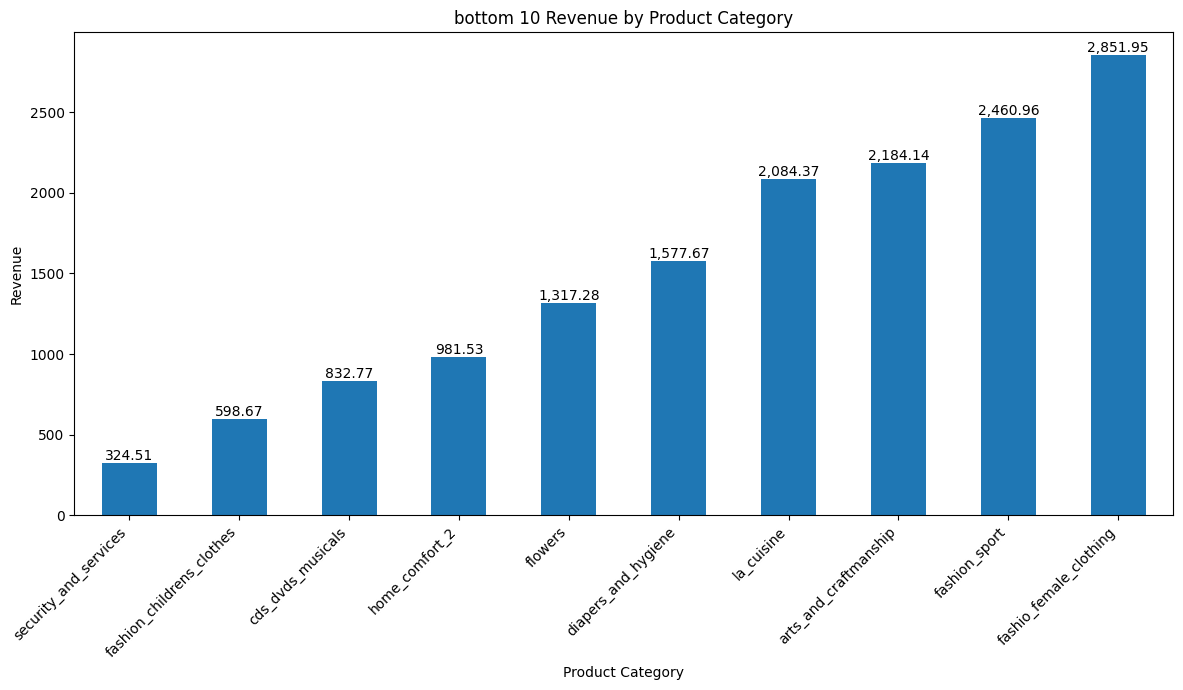

In [ ]:
#bottom categories
top_categories = df_clean.groupby('product_category_name_english')['revenue'].sum().sort_values().head(10)

plt.figure(figsize=(12, 7))
ax = top_categories.plot(kind='bar')
plt.title('bottom 10 Revenue by Product Category')
plt.xlabel('Product Category') # X-axis is Product Category
plt.ylabel('Revenue') # Y-axis is  Revenue

# Add values on each bar
for index, value in enumerate(top_categories):
    ax.text(index, value, f'{value:,.2f}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

### 8.5 Average Order Value (AOV) per Month

/tmp/ipykernel_9578/4188093316.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  AOV= df_clean.groupby('order_month').apply(lambda x: x['payment_value'].sum() / x['order_id'].nunique()).plot(kind='line')


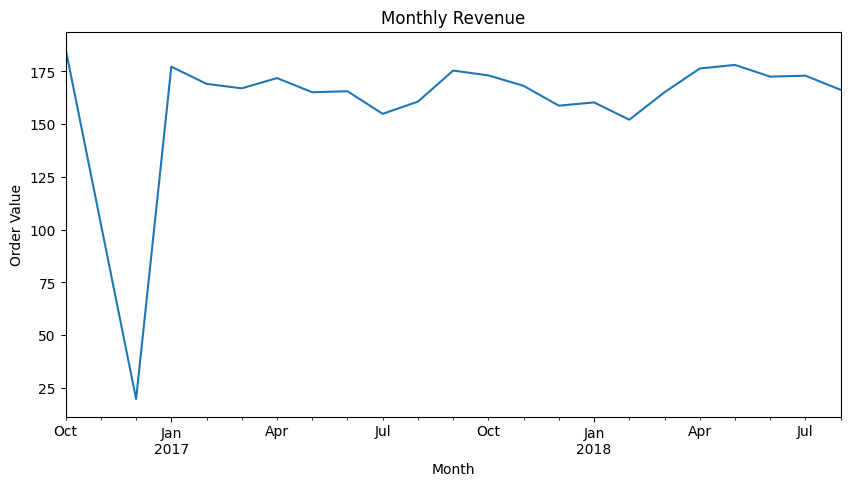

In [ ]:
#average order value per month
plt.figure(figsize=(10,5))
AOV= df_clean.groupby('order_month').apply(lambda x: x['payment_value'].sum() / x['order_id'].nunique()).plot(kind='line')

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Order Value')
plt.show()

### 8.6 Payment Type Distribution

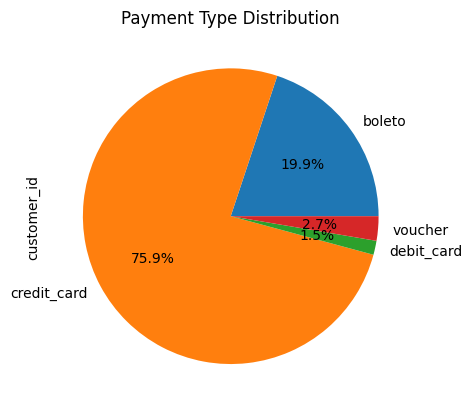

In [ ]:
#payment type distribution
types=df_clean.groupby('payment_type')['customer_id'].nunique()
types.plot(kind='pie',autopct='%1.1f%%')
plt.title('Payment Type Distribution')
plt.show()


### 8.7 Payment Installments vs Order Value

Do customers who pay in more installments spend more overall?

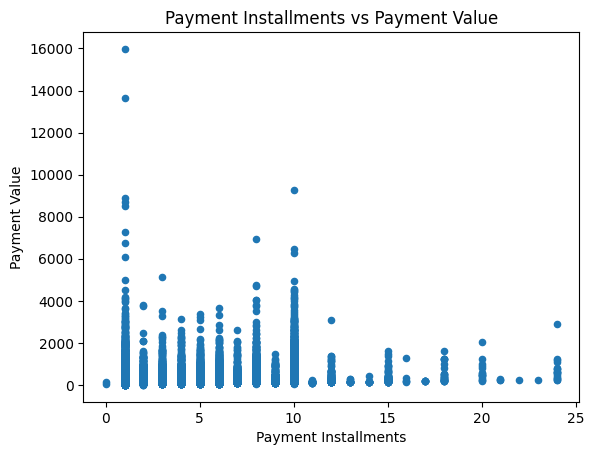

In [ ]:
#how installments influence paument value
installment=df_clean.groupby(['customer_id','payment_installments'])['payment_value'].sum().reset_index(1)
installment.plot(kind='scatter',x='payment_installments',y='payment_value')
plt.title('Payment Installments vs Payment Value')
plt.xlabel('Payment Installments')
plt.ylabel('Payment Value')
plt.show()

**Section Finding:**
- Revenue grew consistently from late 2016 through mid-2018.
- The top 3 categories drive the majority of platform revenue.
- Credit card is the dominant payment method. Many customers split payments into installments, suggesting price sensitivity.

#Delivery and operations

## 9. Delivery & Operations Analysis

Understanding delivery performance, on-time rates, and the impact of late delivery on customer satisfaction.

### 9.1 Delivery Time Distribution

How are delivery times distributed across all delivered orders? Where is the mean and median?

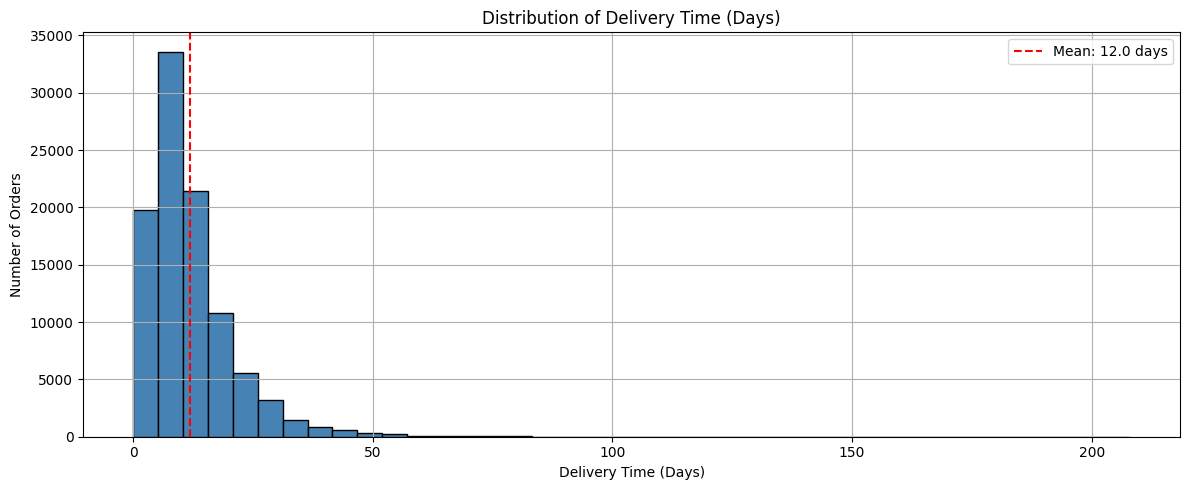

In [ ]:
plt.figure(figsize=(12, 5))
df_clean['delivery_time'].dropna().hist(bins=40, edgecolor='black', color='steelblue')
plt.title('Distribution of Delivery Time (Days)')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.axvline(df_clean['delivery_time'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['delivery_time'].mean():.1f} days")
plt.legend()
plt.tight_layout()
plt.show()

### 9.2 Average Delivery Time by State

Which states have the worst delivery experience?

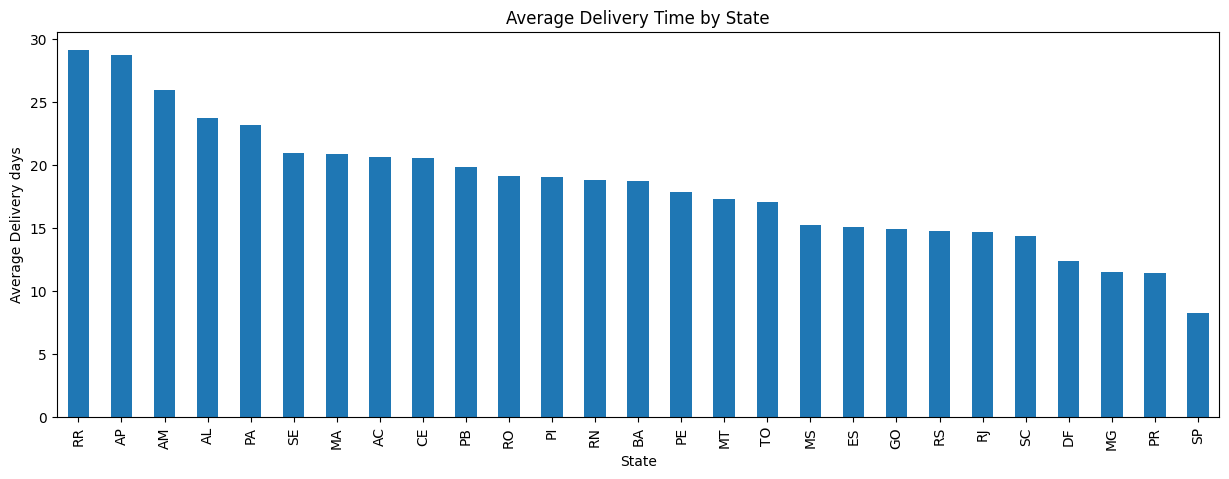

In [ ]:
#average delivery time by state
plt.figure(figsize=(15,5) )
df_clean.groupby('customer_state')['delivery_time'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Delivery Time by State')
plt.xlabel('State')
plt.ylabel('Average Delivery days')
plt.show()



### 9.3 On-Time vs Late Delivery — Overall Rate

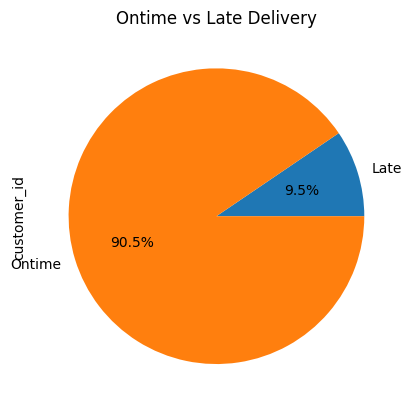

In [ ]:
#ontime vs late delivery
df_clean.groupby('actual_delivery_time')['customer_id'].nunique().plot(kind='pie',autopct='%1.1f%%')
plt.title('Ontime vs Late Delivery')
plt.show()

### 9.4 States with Worst On-Time Delivery Performance

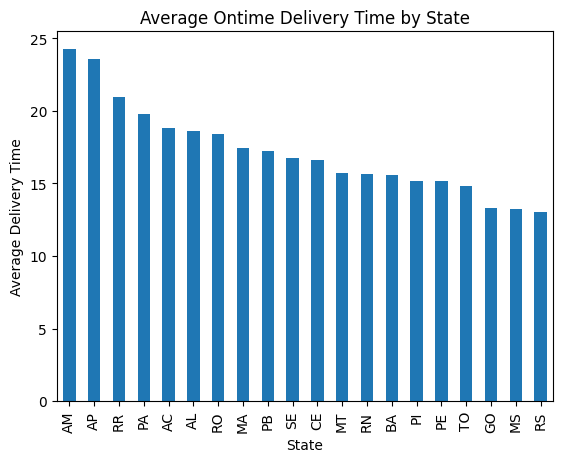

In [ ]:
#state with worst ontime delivery
df_clean[df_clean['actual_delivery_time']=='Ontime'].groupby('customer_state')['delivery_time'].mean().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Average Ontime Delivery Time by State')
plt.xlabel('State')
plt.ylabel('Average Delivery Time')
plt.show()



### 9.5 Impact of Late Delivery on Review Score

Does being late actually hurt customer satisfaction? Boxplot comparison.

Text(0, 0.5, 'Review Score')

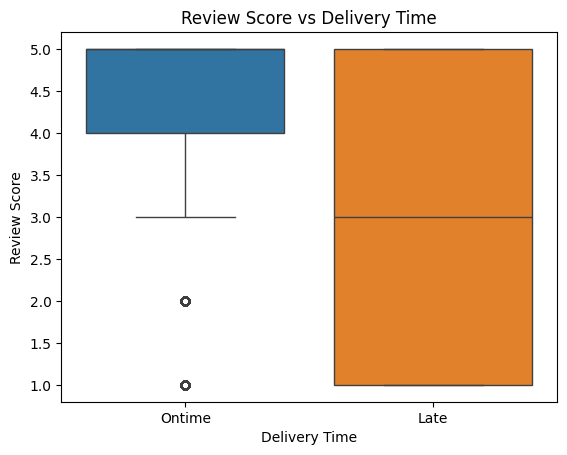

In [ ]:
sns.boxplot(data=df_clean,x='actual_delivery_time',y='review_score',hue='actual_delivery_time')
plt.title('Review Score vs Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Review Score')

### 9.6 Monthly Late Delivery Count

Is the late delivery problem getting better or worse over time?

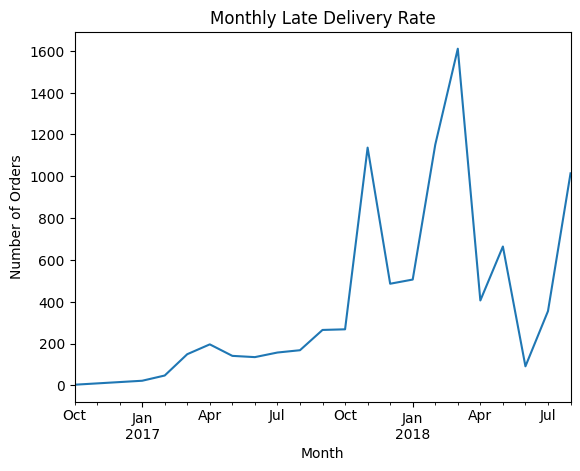

In [ ]:
#monthly late delivery rate
df_clean[df_clean['actual_delivery_time']=='Late'].groupby('order_month')['customer_id'].nunique().plot(kind='line')
plt.title('Monthly Late Delivery Rate')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()
#

### 9.7 Delivery Time vs Review Score

Scatter plot — does longer delivery directly correlate with lower review scores?

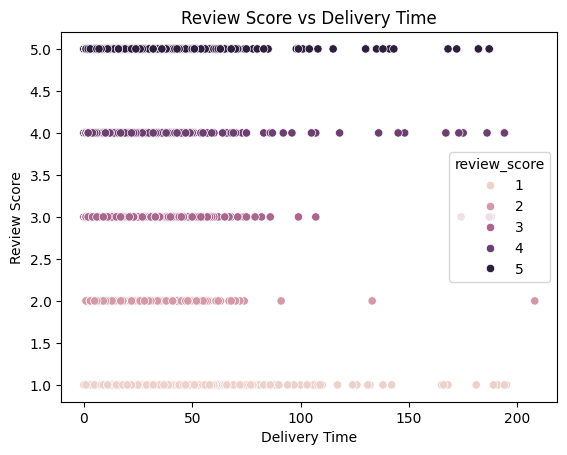

In [ ]:
#delivery days vs review score
sns.scatterplot(data=df_clean,x='delivery_time',y='review_score',hue='review_score')
plt.title('Review Score vs Delivery Time')
plt.ylabel('Review Score')
plt.xlabel('Delivery Time')
plt.show()

**Section Finding:**
- A significant portion of orders are delivered late. Northern and northeastern states are worst affected.
- Late deliveries receive noticeably lower review scores than on-time deliveries — delivery performance directly drives satisfaction.
- The late delivery count grew through 2017 as order volumes scaled, suggesting logistics did not keep pace with growth.

#Customer behaviour analysis

## 10. Customer Behaviour Analysis

Understanding where customers are, how loyal they are, and which categories and states have the best/worst satisfaction.

### 10.1 Top 20 Cities by Unique Customers

Text(0, 0.5, 'Number of Customers')

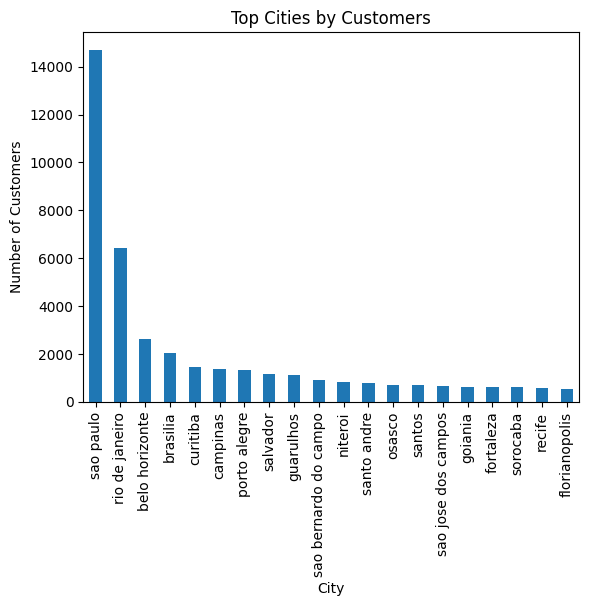

In [ ]:
#top citis by customers
df_clean.groupby('customer_city')['customer_id'].nunique().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top Cities by Customers')
plt.xlabel('City')
plt.ylabel('Number of Customers')

### 10.2 Top 20 States by Revenue

Text(0, 0.5, 'Revenue')

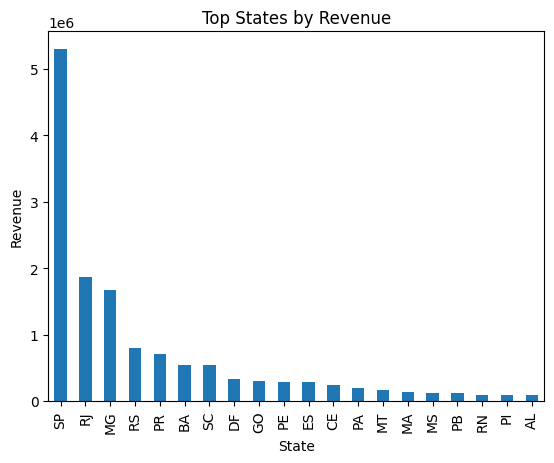

In [ ]:
#top states by revenue
df_clean.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

### 10.3 Repeat Purchase Rate

#### Top 30 Customers by Order Count

Text(0, 0.5, 'Number of Orders')

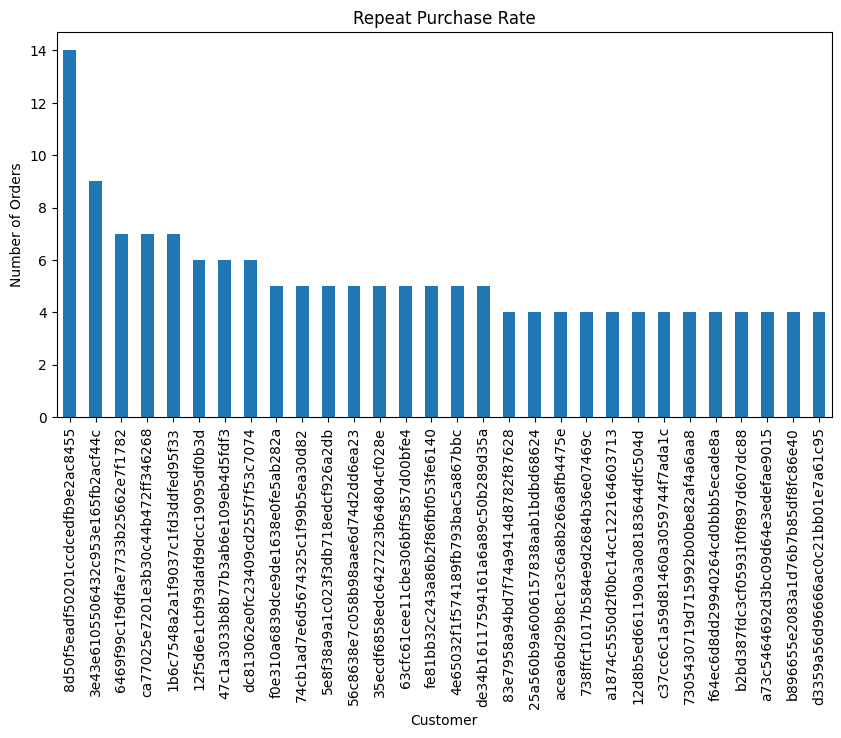

In [ ]:
#repeat purchase rate by top customer
plt.figure(figsize=(10,5))
df_clean.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False).head(30).plot(kind='bar')
plt.title('Repeat Purchase Rate')
plt.xlabel('Customer')
plt.ylabel('Number of Orders')
#

#### Repeat Purchase Rate — Overall %

Repeat Purchase Rate: 2.96%
Total unique customers: 91,473
Customers with 2+ orders: 2,707


Text(0, 0.5, 'Number of Customers')

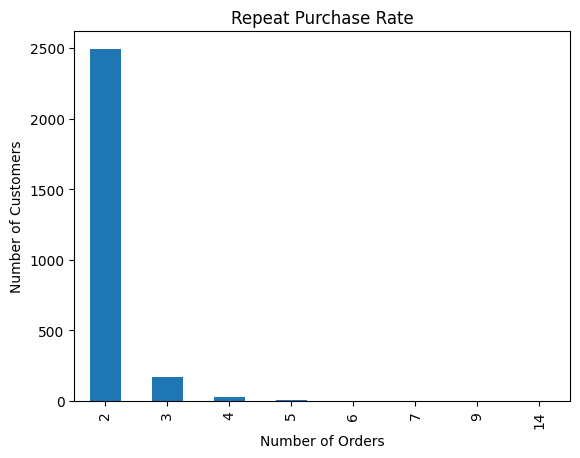

In [ ]:

#repeat purchase rate
customer_orders = df_clean.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (customer_orders > 1).mean() * 100
print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")
print(f"Total unique customers: {customer_orders.shape[0]:,}")
print(f"Customers with 2+ orders: {(customer_orders > 1).sum():,}")

#distribution chart
new=df_clean.groupby('customer_unique_id')['order_id'].nunique().reset_index()
new[new['order_id']>1].groupby('order_id')['customer_unique_id'].count().plot(kind='bar')
plt.title('Repeat Purchase Rate')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')



### 10.4 Review Score Distribution by Order Status

How are review scores distributed? Does order status affect the score?

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

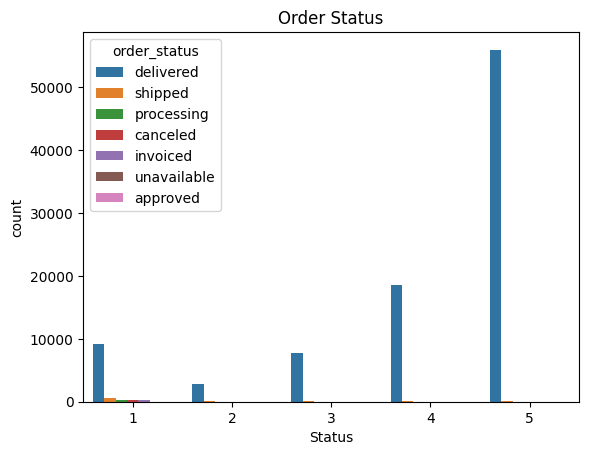

In [ ]:
#review score distribution
df_unique = df.drop_duplicates(subset=['customer_id'], keep='first')
sns.countplot(data=df_unique,x='review_score',hue='order_status')
plt.title('Order Status')
plt.xlabel('Status')
plt

### 10.5 Average Review Score by Product Category

Top 20 best-reviewed categories.

Text(0, 0.5, 'Average Review Score')

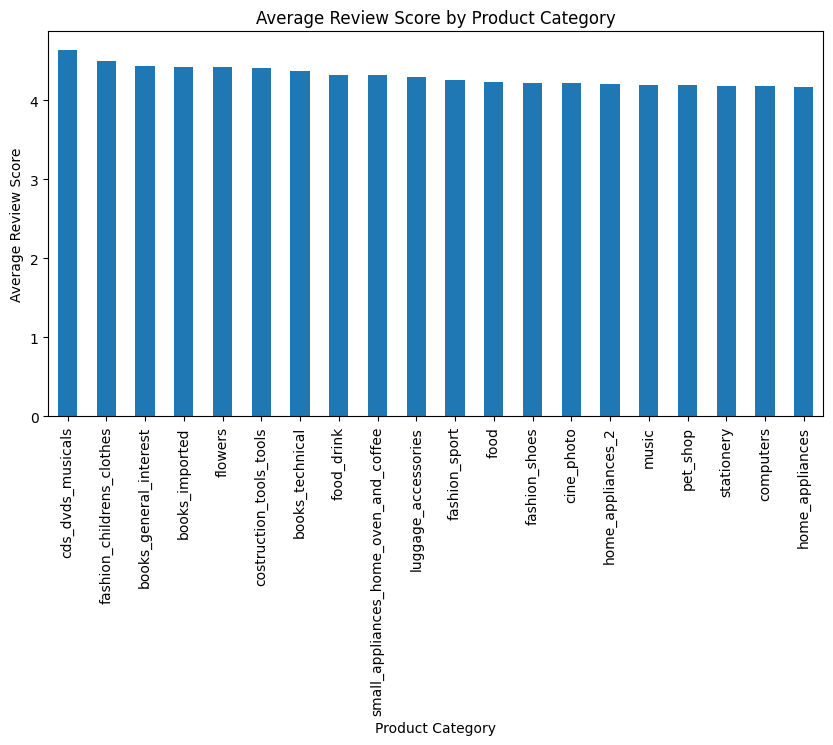

In [ ]:
#avg review score for product categories
plt.figure(figsize=(10,5))
df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Average Review Score by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Review Score')

### 10.6 Average Review Score by State

Which states have the happiest and unhappiest customers?

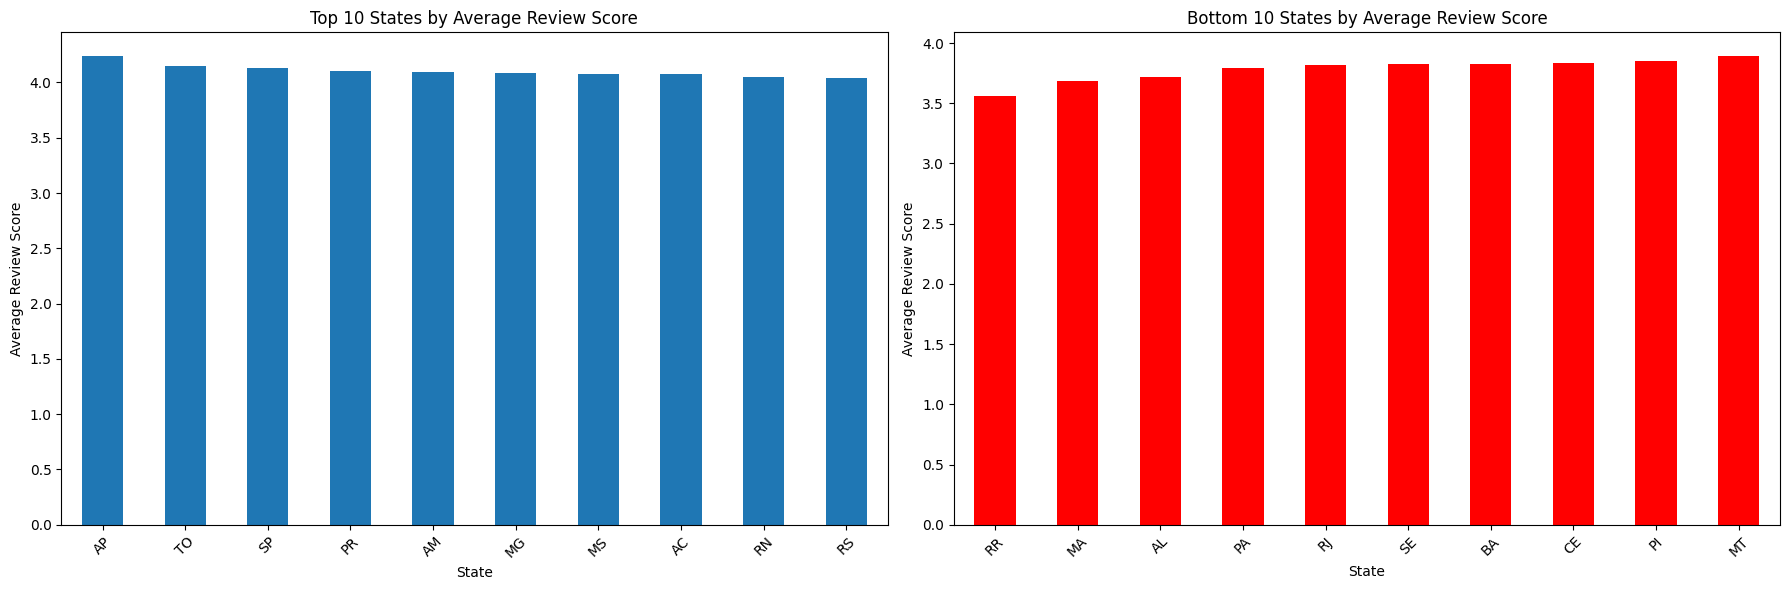

In [ ]:
avg_review_state = df.groupby('customer_state')['review_score'].mean()

# Get top 10 states
top_10_states = avg_review_state.sort_values(ascending=False).head(10)

# Get bottom 10 states
bottom_10_states = avg_review_state.sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot top 10 states
top_10_states.plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 10 States by Average Review Score')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Average Review Score')
axes[0].tick_params(axis='x', rotation=45)

# Plot bottom 10 states
bottom_10_states.plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Bottom 10 States by Average Review Score')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Review Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Rfm analysis


In [ ]:
# snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
# rfm = df.groupby('customer_unique_id').agg(
#     Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
#     Frequency = ('order_id',     'nunique'),
#     Monetary  = ('revenue',  'sum')
# ).reset_index()

# rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
# rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])
# rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
# rfm

In [ ]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id',     'nunique'),
    Monetary   = ('revenue',  'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])

def F_Scores(value):
  if value == 1:
    return 1
  elif value==2 :
    return 2
  elif value==3:
    return 4
  elif value==4:
    return 4
  else:
    return 5
rfm['F_Score'] = rfm['Frequency'].apply(F_Scores)


rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.sort_values(by='Frequency', ascending=False)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
51506,8d50f5eadf50201ccdcedfb9e2ac8455,14,15,820.15,5,5,5,555
22823,3e43e6105506432c953e165fb2acf44c,188,9,1172.67,3,5,5,355
10077,1b6c7548a2a1f9037c1fd3ddfed95f33,201,7,1021.12,3,5,5,355
36755,6469f99c1f9dfae7733b25662e7f1782,68,7,758.83,5,5,5,555
73978,ca77025e7201e3b30c44b472ff346268,94,7,1122.72,5,5,5,555
...,...,...,...,...,...,...,...,...
31576,564988508a81dca36512b04a1ce906f9,273,1,72.43,3,1,2,312
31575,56493fe11c5c9b6159183de0aeaaa971,201,1,62.04,3,1,2,312
31574,564935b7af878f03c1b137d326c005fd,333,1,159.76,2,1,4,214
31573,5648f8f7714f3075cc26b46aaf6ba839,153,1,89.91,4,1,3,413


In [ ]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Check segment distribution
print(rfm['Segment'].value_counts())
print(rfm['Segment'].value_counts(normalize=True).mul(100).round(1))

Segment
Lost                  54387
New Customer          37286
Hibernating             936
Potential Loyalist      568
Champion                118
At Risk                  61
Loyal Customer           40
Name: count, dtype: int64
Segment
Lost                  58.2
New Customer          39.9
Hibernating            1.0
Potential Loyalist     0.6
Champion               0.1
At Risk                0.1
Loyal Customer         0.0
Name: proportion, dtype: float64


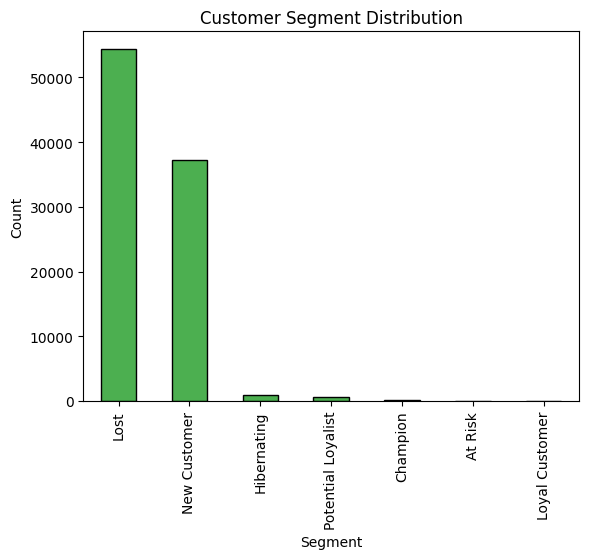

In [ ]:
#customer count in segment category
rfm['Segment'].value_counts().plot(kind='bar',color='#4CAF50',edgecolor='black')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')

plt.show()

/tmp/ipykernel_9578/3508525237.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rfm_heat= rfm.pivot_table(


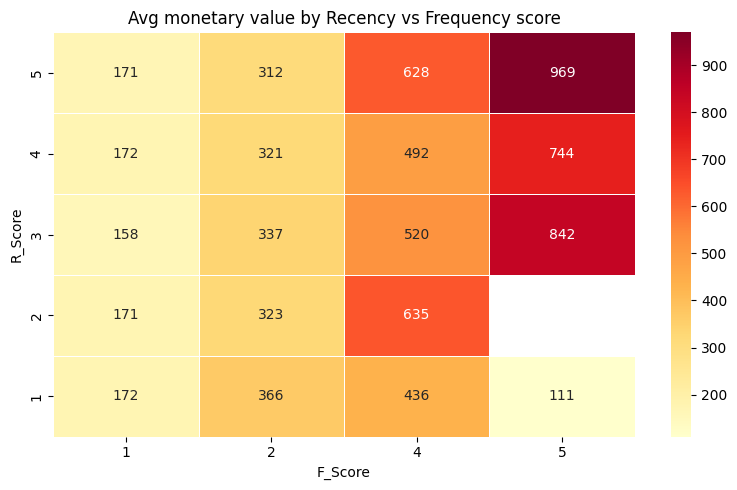

In [ ]:
#RFM heatmap (Avg Monetary by R vs F score):

rfm_heat= rfm.pivot_table(
    index='R_Score',
    columns='F_Score',
    values='Monetary',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap( rfm_heat,annot=True,fmt='.0f',cmap='YlOrRd',linewidths=0.4)
plt.title('Avg monetary value by Recency vs Frequency score')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150)
plt.show()

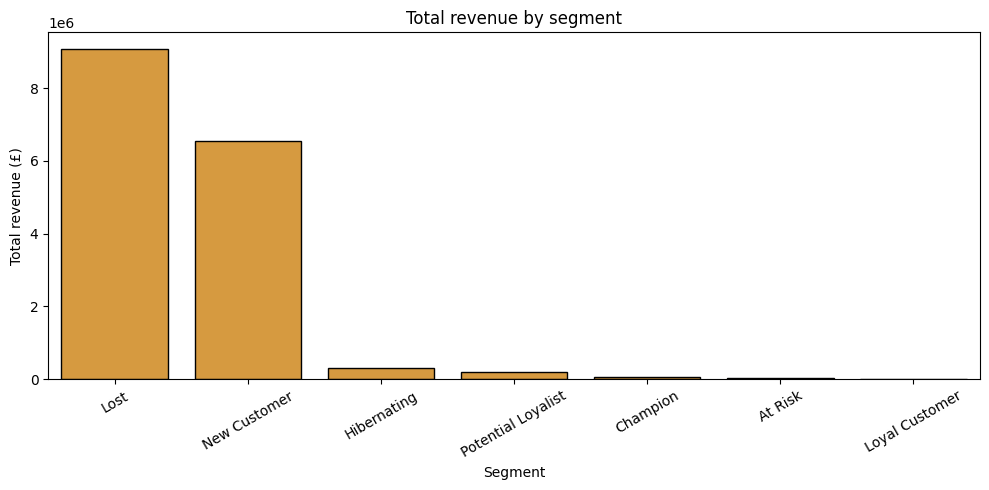

In [ ]:
#revenue distribution per segment
seg_revenue= rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=seg_revenue.index, y=seg_revenue.values, color='#EF9F27', edgecolor='black')
plt.title('Total revenue by segment')
plt.xlabel('Segment')
plt.ylabel('Total revenue (£)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('segment_revenue.png', dpi=150)
plt.show()

In [ ]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 98083 entries, 0 to 115608
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98083 non-null  object        
 1   customer_id                    98083 non-null  object        
 2   order_status                   98083 non-null  object        
 3   order_purchase_timestamp       98083 non-null  datetime64[ns]
 4   order_approved_at              98070 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98082 non-null  object        
 6   order_delivered_customer_date  98083 non-null  datetime64[ns]
 7   order_estimated_delivery_date  98083 non-null  datetime64[ns]
 8   order_item_id                  98083 non-null  int64         
 9   product_id                     98083 non-null  object        
 10  seller_id                      98083 non-null  object        
 11  shipping_limit_date

**Section Finding:**
- Customers are heavily concentrated in São Paulo, Rio de Janeiro, and Belo Horizonte.
- The repeat purchase rate is very low (~3%) — most customers buy once and never return. This is a major retention gap.
- Review score distribution shows most customers are satisfied, but late delivery drives the 1-star segment.

#Seller analysis

## 11. Seller Analysis

Identifying top performers, flagging risk sellers, and understanding delivery accountability at the seller level.

### 11.1 Top 10 Sellers by Revenue

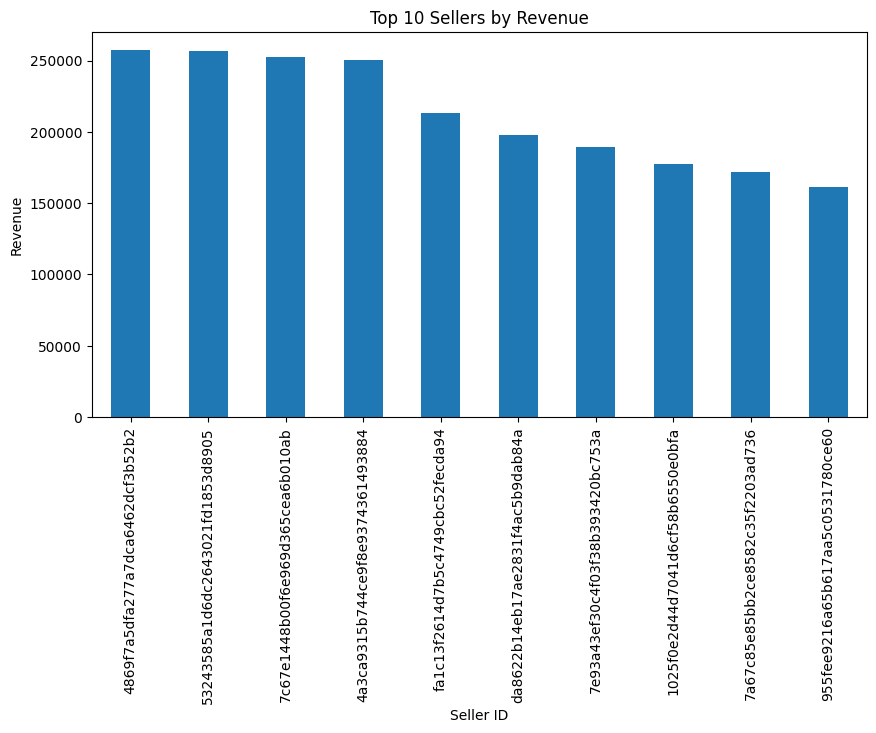

In [ ]:
#top 10 seller by revenue
plt.figure(figsize=(10,5))
df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Revenue')

plt.show()


### 11.2 Seller Summary Table

Aggregated table: total orders, revenue, avg review score, and late delivery rate per seller.

In [ ]:
# seller summary table: total orders, total revenue, avg review score, late delivery rate per seller

seller_summary=df_clean.groupby('seller_id').agg(
    Total_order=('customer_id','nunique'),
    Total_revenue=('revenue','sum'),
    Avg_review=('review_score','mean'))
late_deliveries_per_seller = df_clean[df_clean['actual_delivery_time'] == 'Late'].groupby('seller_id').size()
total_deliveries_per_seller = df_clean.groupby('seller_id').size()
seller_summary['late_delivery_rate'] = round((late_deliveries_per_seller / total_deliveries_per_seller),2)*100
seller_summary['late_delivery_rate'] = seller_summary['late_delivery_rate'].fillna(0) # Fill NaN for sellers with no late deliveries
seller_summary['seller_state']=df_clean.groupby('seller_id')['seller_state'].first()
seller_summary.reset_index(inplace=True)
seller_summary

,seller_id,Total_order,Total_revenue,Avg_review,late_delivery_rate,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2748.06,3.666667,0.0,SP
1,001cca7ae9ae17fb1caed9dfb1094831,192,27498.93,4.046632,7.0,ES
2,002100f778ceb8431b7a1020ff7ab48f,50,1995.16,4.037037,17.0,SP
3,004c9cd9d87a3c30c522c48c4fc07416,143,19226.63,4.144828,10.0,SP
4,00720abe85ba0859807595bbf045a33b,13,917.03,3.666667,20.0,SP
...,...,...,...,...,...,...
2902,ffc470761de7d0232558ba5e786e57b7,27,1797.67,4.321429,11.0,SP
2903,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,2439.23,4.333333,0.0,PR
2904,ffeee66ac5d5a62fe688b9d26f83f534,14,2259.55,4.214286,14.0,SP
2905,fffd5413c0700ac820c7069d66d98c89,56,10614.61,3.892857,12.0,SP


In [ ]:
seller_summary.to_csv('seller_summary.csv', index=False)

### 11.3 Revenue vs Review Score — Seller Scatter

Identifying the risk quadrant: high revenue but low satisfaction.

Text(0.5, 0, 'Average Review Score')

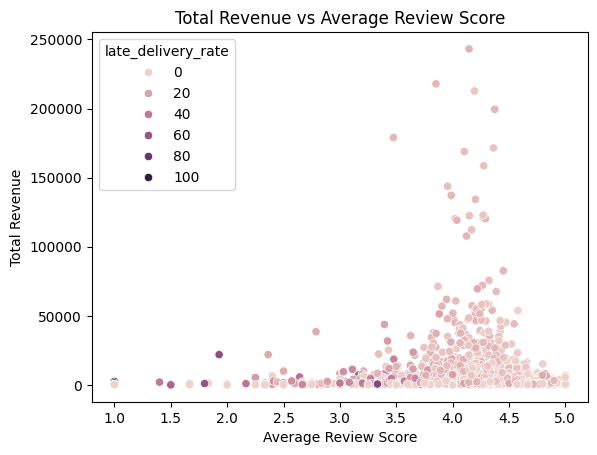

In [ ]:
sns.scatterplot(data= seller_summary, x='Avg_review', y='Total_revenue', hue='late_delivery_rate')
plt.title('Total Revenue vs Average Review Score')
plt.ylabel('Total Revenue')
plt.xlabel('Average Review Score')

### 11.4 Risk Sellers

Sellers with **above-median revenue** AND **avg review score below 3.0** — high business impact but actively harming platform satisfaction.

In [ ]:
risk_sellers = seller_summary[
    (seller_summary['Total_revenue'] > seller_summary['Total_revenue'].median()) &
    (seller_summary['Avg_review'] < 3.0)
]
risk_sellers

,seller_id,Total_order,Total_revenue,Avg_review,late_delivery_rate,seller_state
28,02d35243ea2e497335cd0f076b45675d,14,5803.74,2.642857,43.0,PR
205,1284de4ae8aa26997e748c851557cf0e,3,1546.84,2.666667,0.0,GO
230,1444c08e64d55fb3c25f0f09c07ffcf2,1,2818.74,1.000000,0.0,SP
299,1b65c144b17e607c0f37f10bb7dfec8d,5,1254.35,2.000000,0.0,RJ
411,2528744c5ef5d955adc318720a94d2e7,5,6508.70,2.400000,0.0,SP
530,2eb70248d66e0e3ef83659f71b244378,183,38531.80,2.788043,17.0,RJ
553,30c7f28fd3a5897b2c82d152bb760c17,5,2038.36,1.400000,40.0,MG
566,327b89b872c14d1c0be7235ef4871685,3,1258.80,2.333333,67.0,MG
734,4091f77d8c768fc3e81c20761471761d,8,1309.87,2.750000,38.0,SC
736,40db9e9aa57f7bb151bcda6b0f9bdbb7,11,21925.38,2.363636,18.0,SP


### 11.5 Top 10 Sellers by Late Delivery Rate

Filtered to sellers with more than 20 orders to ensure statistical fairness.

Text(0, 0.5, 'Late Delivery Rate')

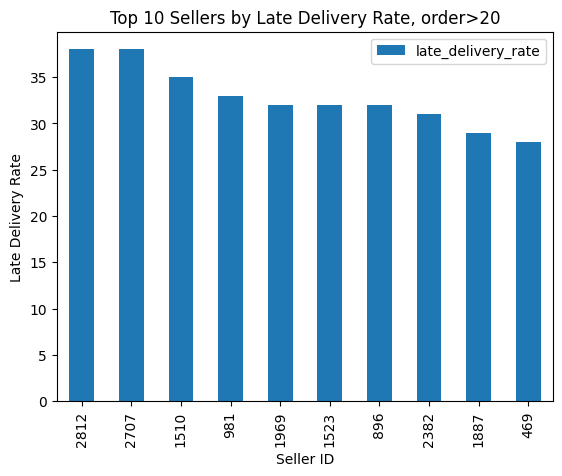

In [ ]:
# top 10 seller by late delivery rate , order>20
late_seller= seller_summary[seller_summary['Total_order']>20]
late_seller= late_seller.sort_values(by='late_delivery_rate',ascending=False).head(10)
late_seller.plot(kind='bar',y='late_delivery_rate')
plt.title('Top 10 Sellers by Late Delivery Rate, order>20')
plt.xlabel('Seller ID')
plt.ylabel('Late Delivery Rate')


### 11.6 Seller State Analysis

Adding seller state to the summary table, then analysing geographic distribution.

In [ ]:
seller_summary['Seller_state']=df_clean.groupby('seller_id')['customer_state'].first()

Top 10 states by average seller revenue, and top 10 states by number of sellers.

<Axes: xlabel='seller_state'>

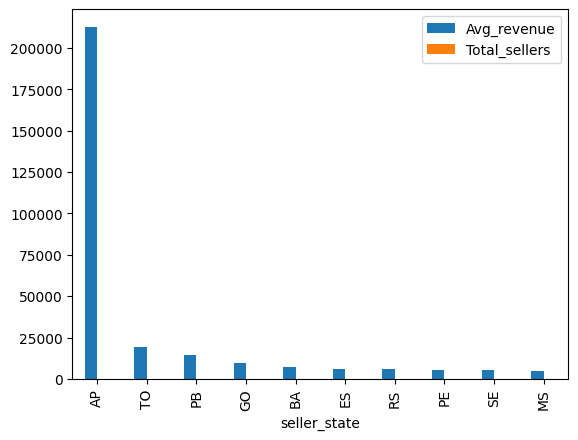

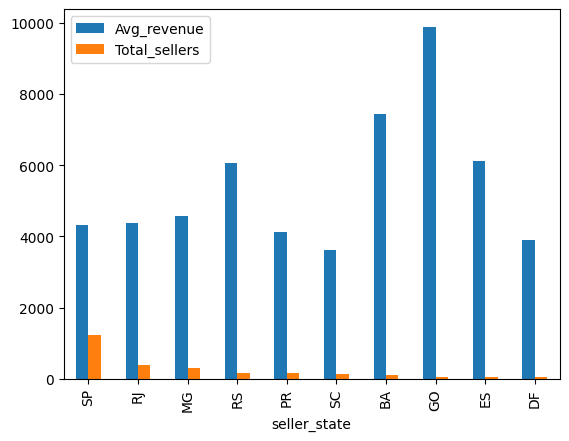

In [ ]:
#top 10 states with max sellers and max avg revenue
states= (seller_summary.groupby('seller_state').agg(Total_sellers= ('seller_state','count'), Avg_revenue=('Total_revenue','mean'))).reset_index()
states.sort_values(by='Avg_revenue',ascending=False).head(10).plot(x='seller_state',y=['Avg_revenue','Total_sellers'],kind='bar')
states.sort_values(by='Total_sellers',ascending=False).head(10).plot(x='seller_state',y=['Avg_revenue','Total_sellers'],kind='bar')

**Section Finding:**
- A small number of top sellers account for a disproportionate share of total revenue.
- Risk sellers handle a significant number of orders while consistently delivering poor customer experiences.
- Sellers are heavily concentrated in São Paulo state, mirroring the customer concentration.

---

## 12. Key Findings & Recommendations

### Finding 1 — Revenue Concentration
The top 3 categories drive the majority of platform revenue.  
**Recommendation:** Increase inventory depth and marketing spend in top categories. Recruit more quality sellers for these categories.

### Finding 2 — Delivery is the Biggest Operational Risk
Northern and northeastern states wait significantly longer than the national average. Late deliveries directly lower review scores.  
**Recommendation:** Partner with regional logistics providers in underserved states. Set state-level SLA targets.

### Finding 3 — Customer Retention is Critically Low
Only ~3% of customers make a repeat purchase.  
**Recommendation:** Introduce a post-purchase email sequence or loyalty discount on the second order. Retention is far cheaper than acquisition.

### Finding 4 — Risk Sellers Need Intervention
A subset of sellers generate significant revenue but consistently deliver poor satisfaction.  
**Recommendation:** Implement a Seller Quality Score. Give underperforming sellers a 90-day improvement plan before suspension.

---
*Analysis by: [Krishna Kumar Agrawal] | Dataset: Olist Brazilian E-Commerce (2016–2018) | Tools: Python, Pandas, Matplotlib, Seaborn*